In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.common import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag50Pd50_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.5) # 0.1
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_rel, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.5

# BF
Errors too large. Gact2_0 prior truncated to stop it from having a long left tail 

In [ ]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH# -> COOH* + # (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.65)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF)

ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF, loo_BF); plot_coverages(trace_BF)

# ER
Good simple model. ER should have the highest DRC 

In [ ]:
with pm.Model() as ER:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER, loo_ER = fit_and_evaluate(ER)

ppc_ER = plot_posteriors(trace_ER, ER)
plot_model_fits(trace_ER, ppc_ER, loo_ER); plot_coverages(trace_ER)

# BF ER
Bifunctional also has significant DRC - but ER has the highest DRC

In [ ]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH# -> COOH* + # (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH# + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - E_in
    Gact2_BF = Gact2_BF_0
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER)

ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER, loo_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# BF PCT
beta for the coupling step fits to zero - the coupling step is not a function of potential and is completely chemical (i.e electron transfer happens after the chemical step is over)

In [ ]:
with pm.Model() as BF_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=1, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.6)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF_PCT, loo_BF_PCT = fit_and_evaluate(BF_PCT, target_accept=0.95)

ppc_BF_PCT = plot_posteriors(trace_BF_PCT, BF_PCT)
plot_model_fits(trace_BF_PCT, ppc_BF_PCT, loo_BF_PCT); plot_coverages(trace_BF_PCT)

# BF PCT Lateral

Progress,Draws,Divergences,Step Size,Gradients/Draw
,150,28,0.05,3
,150,0,0.07,15
,150,1,0.43,63
,150,0,0.04,127


c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.57 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 200 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -9002.33   344.80
p_loo     9691.13        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.57]   (good)     1158   78.5%
   (0.57, 1]   (bad)       120    8.1%
   (1, Inf)   (very bad)  198   13.4%



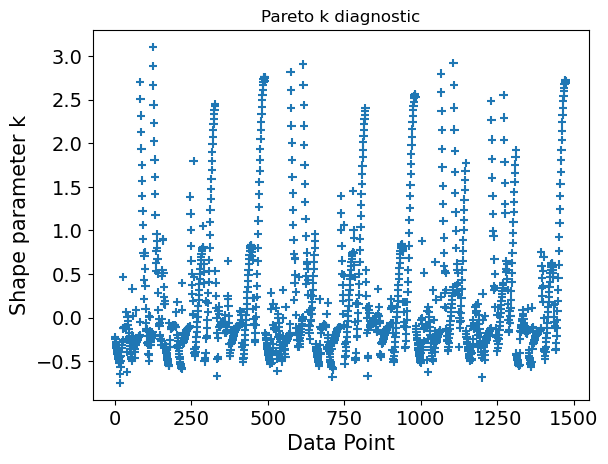

                    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0          0.129  0.090   0.036    0.249      0.039    0.015       5.0       7.0   2.81
deltaG5_0          0.007  0.147  -0.148    0.240      0.069    0.033       5.0      42.0   3.38
deltaG1_0         -1.709  0.625  -2.342   -0.692      0.291    0.110       5.0      12.0   4.19
q                  0.344  0.136   0.250    0.605      0.063    0.039       5.0      13.0   3.58
Gact2_0            1.642  0.454   1.030    2.123      0.212    0.038       5.0      13.0   4.09
z_CO_CO            1.549  0.605   0.562    2.138      0.282    0.106       5.0      13.0   4.20
sigma_rel          0.284  0.018   0.261    0.304      0.008    0.002       5.0      13.0   3.45
CO_converge_error  0.000  0.000   0.000    0.000      0.000    0.000       5.0      13.0   3.05


Sampling: [Gact2_0, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel, z_CO_CO]



--- Prior-to-Posterior Contraction ---
deltaG4_0: 0.792
deltaG5_0: 0.465
deltaG1_0: -9.818
q: 0.783
Gact2_0: -9.758
z_CO_CO: -24.536
sigma_rel: 0.996
CO_converge_error: 0.784


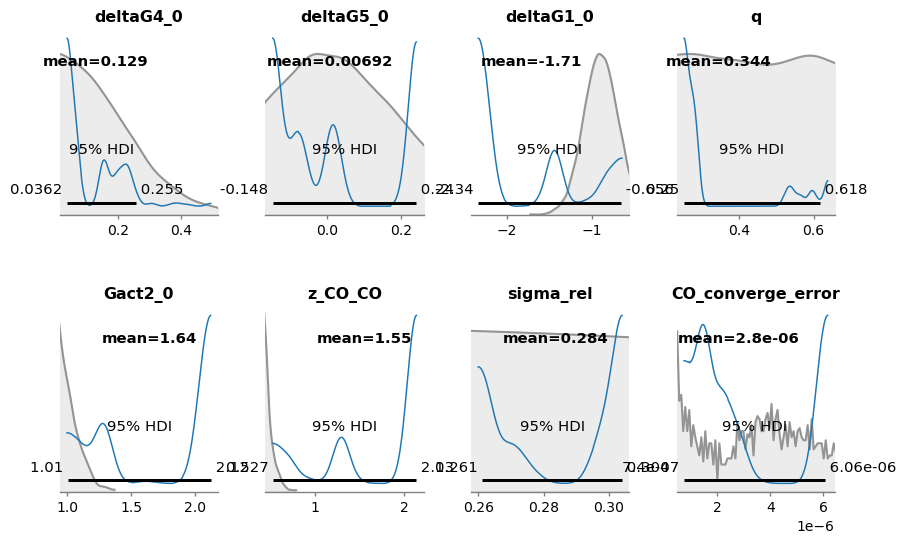

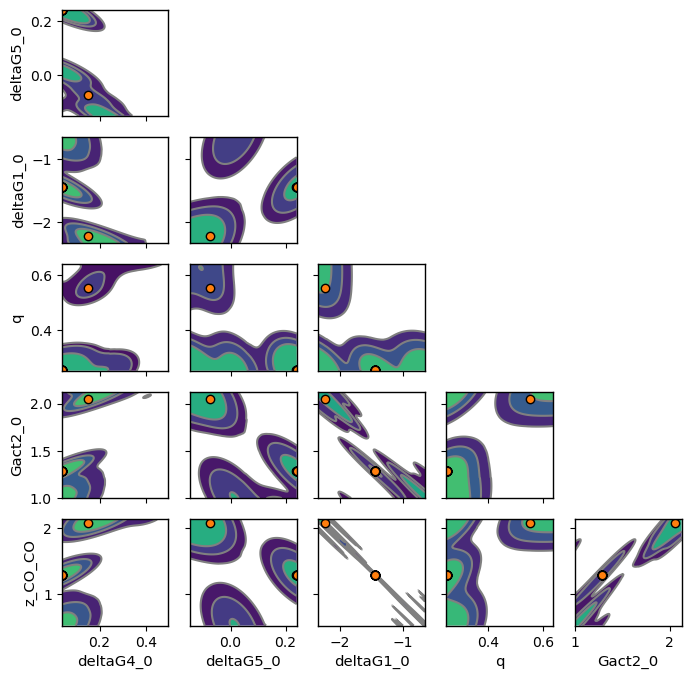

Sampling: [rate]


rate: 0.583


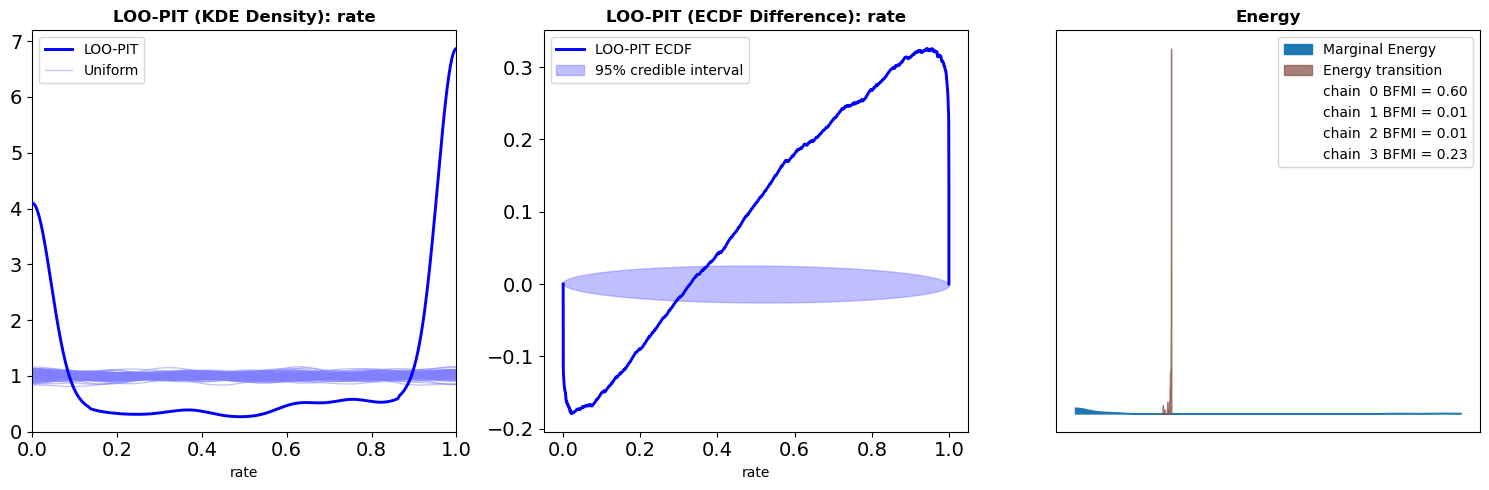

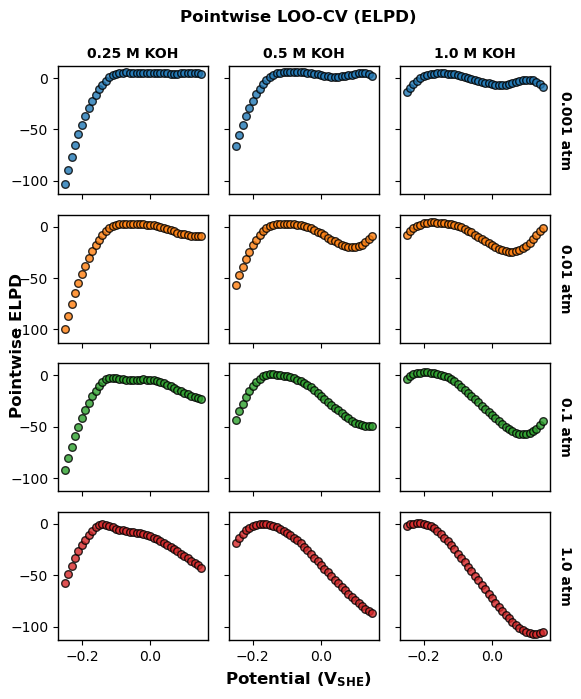

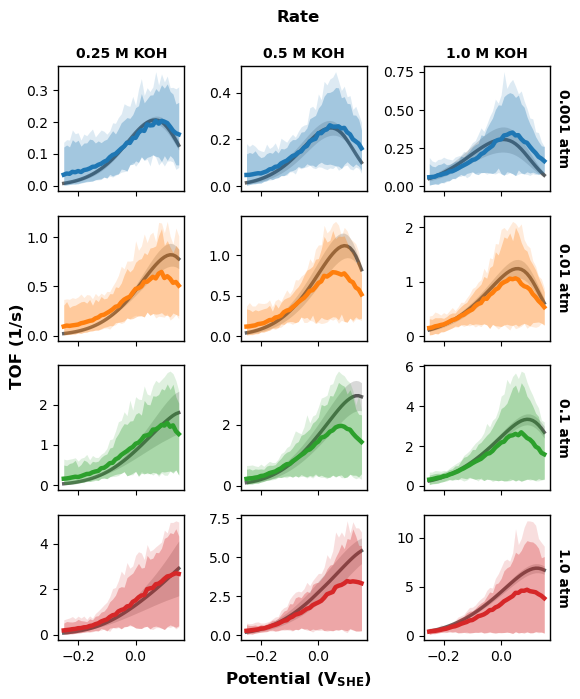

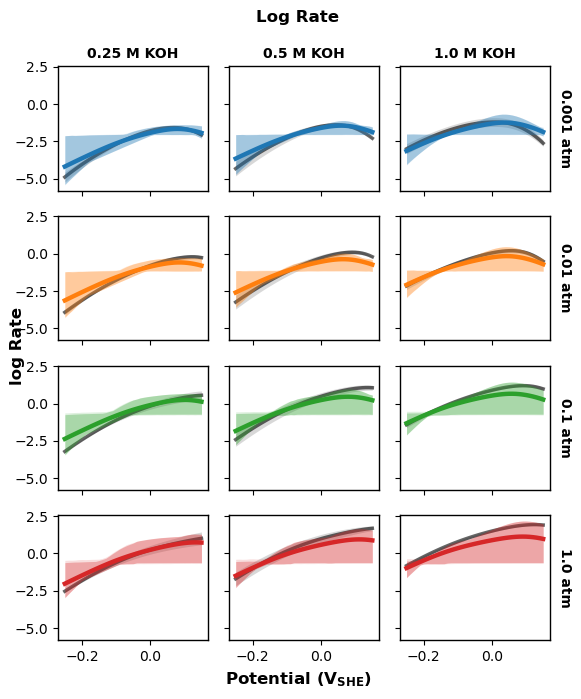

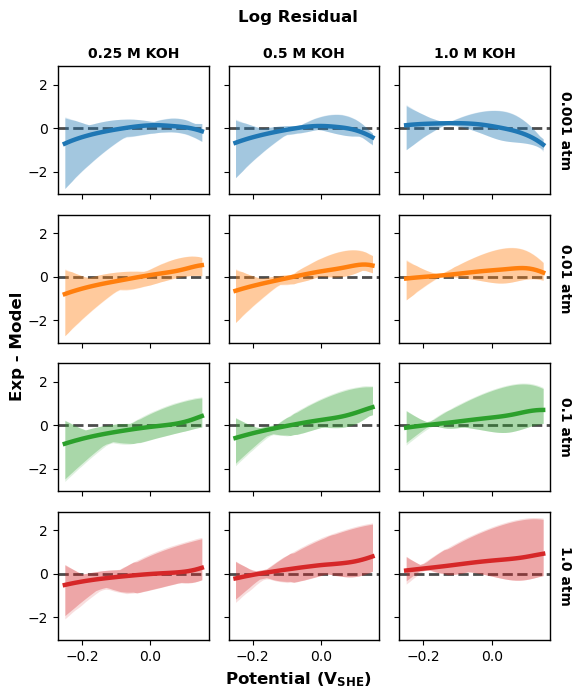

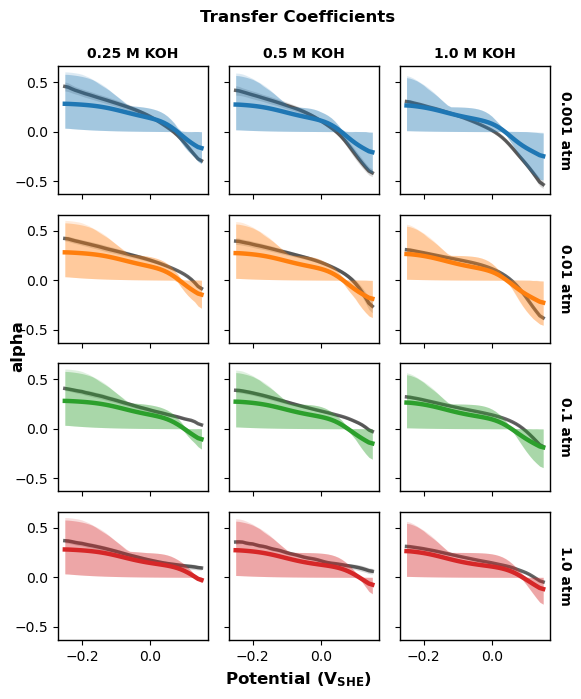

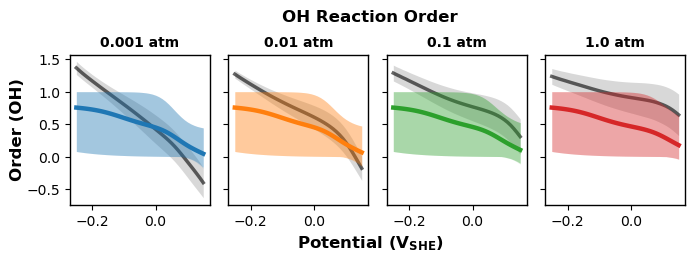

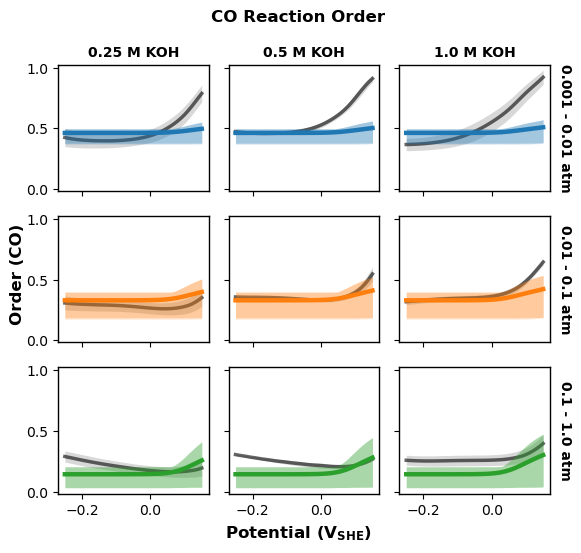

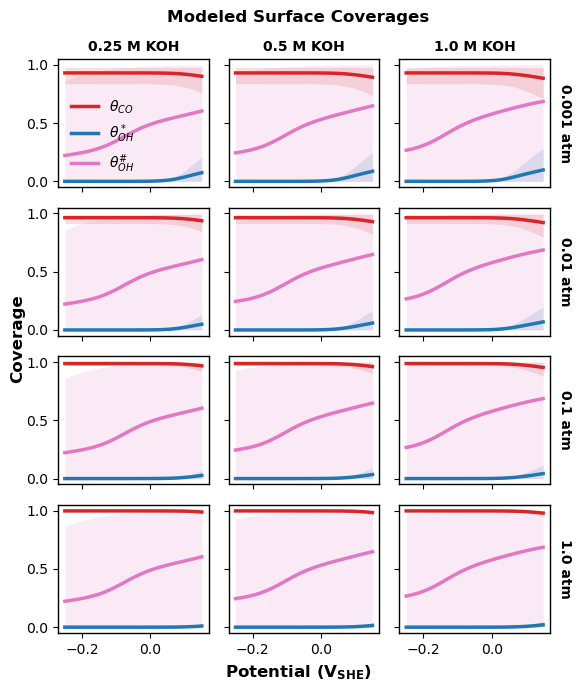

In [2]:
with pm.Model() as BF_PCT_lateral:
    '''
    1. CO + * <-> CO* (QEA) (Frumkin)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF) (BEP)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA) (Frumkin)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA) (Frumkin)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.9, sigma=0.2, upper=-0.5)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = 0 # pm.Beta('beta_2', alpha=1, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.6)
    z_CO_CO = pm.TruncatedNormal('z_CO_CO', mu=0.0, sigma=0.2, lower=0.0)
    z_OH_CO = pt.as_tensor_variable(0.0) # pm.Normal('z_OH_CO', mu=0.0, sigma=0.2)
    z_CO_OH = pt.as_tensor_variable(0.0) # pm.Normal('z_CO_OH', mu=0.0, sigma=0.2)
    z_OH_OH = pt.as_tensor_variable(0.0) # pm.Normal('z_OH_OH', mu=0.0, sigma=0.2)

    bep_alpha = 0.65; n_iter_steps = 24

    # Thermodynamics 
    deltaG1_base = deltaG1_0
    deltaG4_base = deltaG4_0 - E_in
    deltaG5_base = deltaG5_0 - q * E_in
    Gact2_base = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1_base = -deltaG1_base/(kb_eV*T)
    log_K4_base = -deltaG4_base/(kb_eV*T)
    log_K5_base = -deltaG5_base/(kb_eV*T)
    log_k2_base = np.log(kb_J*T/h) - Gact2_base/(kb_eV*T)
    
    term_CO_base = log_K1_base + np.log(P_CO_in)
    term_OH_Pd_base = log_K4_base + np.log(C_KOH_in)
    term_OH_Ag_base = log_K5_base + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO_base)
    log_theta_Pd_init = -pt.logsumexp(pt.stack([zeros, term_CO_base, term_OH_Pd_base]), axis=0)
    log_theta_Ag_init = -pt.logsumexp(pt.stack([zeros, term_OH_Ag_base]), axis=0)
    theta_CO_guess = pt.exp(term_CO_base + log_theta_Pd_init)
    theta_OH_star_guess = pt.exp(term_OH_Pd_base + log_theta_Pd_init)
    theta_OH_pound_guess = pt.exp(term_OH_Ag_base + log_theta_Ag_init)

    damp_array = pt.as_tensor_variable(np.maximum(0.6 * (0.80 ** np.arange(n_iter_steps)), 0.05))    
    def frumkin_step(damp, theta_CO_prev, theta_OH_star_prev, theta_OH_pound_prev, 
                     log_K1_base, log_K4_base, log_K5_base, 
                     z_CO_CO, z_OH_CO, z_CO_OH, z_OH_OH, kb_T, zeros, P_CO, C_KOH):
        
        theta_OH_tot_prev = theta_OH_star_prev + theta_OH_pound_prev
        penalty_CO = (z_CO_CO * theta_CO_prev + z_CO_OH * theta_OH_tot_prev) / kb_T
        penalty_OH = (z_OH_CO * theta_CO_prev + z_OH_OH * theta_OH_tot_prev) / kb_T
        log_K1_iter = log_K1_base - penalty_CO
        log_K4_iter = log_K4_base - penalty_OH
        log_K5_iter = log_K5_base - penalty_OH
        term_CO_iter = log_K1_iter + np.log(P_CO)
        term_OH_Pd_iter = log_K4_iter + np.log(C_KOH)
        term_OH_Ag_iter = log_K5_iter + np.log(C_KOH)
        
        log_theta_Pd_iter = -pt.logsumexp(pt.stack([zeros, term_CO_iter, term_OH_Pd_iter]), axis=0)
        log_theta_Ag_iter = -pt.logsumexp(pt.stack([zeros, term_OH_Ag_iter]), axis=0)
        theta_CO_calc = pt.exp(term_CO_iter + log_theta_Pd_iter)
        theta_OH_star_calc = pt.exp(term_OH_Pd_iter + log_theta_Pd_iter)
        theta_OH_pound_calc = pt.exp(term_OH_Ag_iter + log_theta_Ag_iter)

        theta_CO_new = damp * theta_CO_calc + (1.0 - damp) * theta_CO_prev
        theta_OH_star_new = damp * theta_OH_star_calc + (1.0 - damp) * theta_OH_star_prev
        theta_OH_pound_new = damp * theta_OH_pound_calc + (1.0 - damp) * theta_OH_pound_prev
        return theta_CO_new, theta_OH_star_new, theta_OH_pound_new

    outputs = pytensor.scan(fn=frumkin_step, sequences=[damp_array], 
        outputs_info=[theta_CO_guess, theta_OH_star_guess, theta_OH_pound_guess],
        non_sequences=[log_K1_base, log_K4_base, log_K5_base, z_CO_CO, z_OH_CO, z_CO_OH, z_OH_OH, kb_eV*T, zeros, pt.as_tensor_variable(P_CO_in), pt.as_tensor_variable(C_KOH_in)], 
        n_steps=n_iter_steps, strict=True, return_updates=False)

    theta_CO_seq, theta_OH_star_seq, theta_OH_pound_seq = outputs
    theta_CO_final = theta_CO_seq[-1]
    theta_OH_star_final = theta_OH_star_seq[-1]
    theta_OH_pound_final = theta_OH_pound_seq[-1]

    pm.Deterministic('CO_converge_error', pt.max(pt.abs(theta_CO_seq[-1] - theta_CO_seq[-2])))
    # pm.Deterministic('OH_star_converge_error', pt.max(pt.abs(theta_OH_star_seq[-1] - theta_OH_star_seq[-2])))
    # pm.Deterministic('OH_pound_converge_error', pt.max(pt.abs(theta_OH_pound_seq[-1] - theta_OH_pound_seq[-2])))

    theta_OH_tot_final = theta_OH_star_final + theta_OH_pound_final
    penalty_CO_final = (z_CO_CO * theta_CO_final + z_CO_OH * theta_OH_tot_final) / (kb_eV*T)
    penalty_OH_final = (z_OH_CO * theta_CO_final + z_OH_OH * theta_OH_tot_final) / (kb_eV*T)
    log_K1_final = log_K1_base - penalty_CO_final
    log_K4_final = log_K4_base - penalty_OH_final
    log_K5_final = log_K5_base - penalty_OH_final
    log_k2_final = log_k2_base + bep_alpha * (penalty_CO_final + penalty_OH_final)
    term_CO_final = log_K1_final + np.log(P_CO_in)
    term_OH_Pd_final = log_K4_final + np.log(C_KOH_in)
    term_OH_Ag_final = log_K5_final + np.log(C_KOH_in)
    log_theta_Pd_final = -pt.logsumexp(pt.stack([zeros, term_CO_final, term_OH_Pd_final]), axis=0)
    log_theta_Ag_final = -pt.logsumexp(pt.stack([zeros, term_OH_Ag_final]), axis=0)
    log_theta_CO_final = term_CO_final + log_theta_Pd_final
    log_theta_OH_pound_final = term_OH_Ag_final + log_theta_Ag_final

    pm.Deterministic('theta_CO', pt.exp(log_theta_CO_final))
    pm.Deterministic('theta_OH_star', pt.exp(term_OH_Pd_final + log_theta_Pd_final))
    pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_pound_final))
    pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd_final))
    pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag_final))

    # Rate expression
    log_rate = log_k2_final + log_theta_CO_final + log_theta_OH_pound_final + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_BF_PCT_lateral, loo_BF_PCT_lateral = fit_and_evaluate(BF_PCT_lateral, target_accept=0.7, tune=100, draws=50)

ppc_BF_PCT_lateral = plot_posteriors(trace_BF_PCT_lateral, BF_PCT_lateral)
plot_model_fits(trace_BF_PCT_lateral, ppc_BF_PCT_lateral, loo_BF_PCT_lateral); plot_coverages(trace_BF_PCT_lateral)

# BF ER PCT
Technically a better model but the increase in ELPD is not high enough to warrant two additonal parameters. Not sure what to do about this yet

In [ ]:
with pm.Model() as BF_ER_PCT:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
     # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=1, beta=5)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=1, beta=1)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER_PCT, loo_BF_ER_PCT = fit_and_evaluate(BF_ER_PCT, target_accept=0.95)

ppc_BF_ER_PCT = plot_posteriors(trace_BF_ER_PCT, BF_ER_PCT)
plot_model_fits(trace_BF_ER_PCT, ppc_BF_ER_PCT, loo_BF_ER_PCT); plot_coverages(trace_BF_ER_PCT)
plot_drc(BF_ER_PCT, trace_BF_ER_PCT, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# CO BF PCT Ag 
CO activation energy is significantly high enough. Helps increase ELPD. CO ads is rate limiting at high potentials 

In [ ]:
with pm.Model() as CO_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=1, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.7, sigma=0.2)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2 + log_theta_OH_Ag + np.log(Ag_comp)     
    log_denom_Pd = pt.logsumexp(pt.stack([log_k1_PCO, log_A_Pd + log_k_minus_1, log_A_Pd + log_k_BF_app]), axis=0)

    # Calculate final coverages exactly
    log_theta_CO = log_k1_PCO - log_denom_Pd
    log_theta_Pd = pt.logsumexp(pt.stack([log_k_minus_1 + zeros, log_k_BF_app]), axis=0) - log_denom_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate = log_k_BF_app + log_theta_CO
    rate = observables(log_rate) 

trace_CO_BF_PCT_Ag, loo_CO_BF_PCT_Ag = fit_and_evaluate(CO_BF_PCT_Ag)

ppc_CO_BF_PCT_Ag = plot_posteriors(trace_CO_BF_PCT_Ag, CO_BF_PCT_Ag)
plot_model_fits(trace_CO_BF_PCT_Ag, ppc_CO_BF_PCT_Ag); plot_coverages(trace_CO_BF_PCT_Ag)
plot_drc(CO_BF_PCT_Ag, trace_CO_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact1_0'], perturb_labels=['BF', 'CO ads'])

# OH Ag BF PCT Ag
Multimodal distribution had to be pruned to get this solution and not let OH ads hijack all the DRC

In [ ]:
with pm.Model() as OH_Ag_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=1, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.5)
    Gact5_0 = pm.Normal('Gact5_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_k5_CKOH = log_k5 + np.log(C_KOH_in)
    log_k_minus_5 = log_k5 - log_K5
    log_k2_theta_CO = log_k2 + log_theta_CO
    log_den_Ag = pt.logsumexp(pt.stack([log_k5_CKOH, log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_OH_Ag = log_k5_CKOH - log_den_Ag
    log_num_empty_Ag = pt.logsumexp(pt.stack([log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_empty_Ag = log_num_empty_Ag - log_den_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_empty_Ag))

    # Rate expression 
    log_rate = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    rate = observables(log_rate)
    
trace_OH_Ag_BF_PCT_Ag, loo_OH_Ag_BF_PCT_Ag = fit_and_evaluate(OH_Ag_BF_PCT_Ag)

ppc_OH_Ag_BF_PCT_Ag = plot_posteriors(trace_OH_Ag_BF_PCT_Ag, OH_Ag_BF_PCT_Ag)
plot_model_fits(trace_OH_Ag_BF_PCT_Ag, ppc_OH_Ag_BF_PCT_Ag); plot_coverages(trace_OH_Ag_BF_PCT_Ag)
plot_drc(OH_Ag_BF_PCT_Ag, trace_OH_Ag_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact5_0'], perturb_labels=['BF', 'OH Ag ads'])

# CO OH Ag BF PCT Ag
Priors need to be strangled to go towards OH limited. OH limited has lower error than CO limited. When OH is limited, CO ads limited has zero DRC 

In [ ]:
with pm.Model() as CO_OH_Ag_BF_PCT_Ag:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=1, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Beta('q', alpha=1, beta=1)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.01, upper=0.9)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.5, upper=0.9)
    Gact5_0 = pm.TruncatedNormal('Gact5_0', mu=0.7, sigma=0.2, lower=0.675, upper=0.9)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    k1_PCO = pt.exp(log_k1 + np.log(P_CO_in))
    k_minus_1 = pt.exp(log_k1 - log_K1)
    k2 = pt.exp(log_k2)
    k5_CKOH = pt.exp(log_k5 + np.log(C_KOH_in))
    k_minus_5 = pt.exp(log_k5 - log_K5)
    A_Pd = 1.0 + pt.exp(log_K4 + np.log(C_KOH_in)) 
    a = k1_PCO
    b = A_Pd * k_minus_1
    c = A_Pd * k2
    d = k5_CKOH
    e = k_minus_5
    f = k2
    A_quad = (a + b) * f
    B_quad = (a + b) * (d + e) + c * d - a * f
    C_quad = -a * (d + e)
    theta_CO_val = (-B_quad + pt.sqrt(B_quad**2 - 4.0 * A_quad * C_quad)) / (2.0 * A_quad)
    theta_OH_Ag_val = d / (d + e + f * theta_CO_val)
    theta_empty_Pd_val = (1.0 - theta_CO_val) / A_Pd
    theta_OH_Pd_val = theta_empty_Pd_val * pt.exp(log_K4 + np.log(C_KOH_in))
    theta_empty_Ag_val = 1.0 - theta_OH_Ag_val

    theta_CO = pm.Deterministic('theta_CO', theta_CO_val)
    theta_OH_star = pm.Deterministic('theta_OH_star', theta_OH_Pd_val)
    theta_OH_pound = pm.Deterministic('theta_OH_pound', theta_OH_Ag_val)
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', theta_empty_Pd_val)
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', theta_empty_Ag_val)

    # Rate expression
    log_rate = pt.log(k2) + pt.log(theta_CO_val) + pt.log(theta_OH_Ag_val) + np.log(Ag_comp)
    rate = observables(log_rate) 

trace_CO_OH_Ag_BF_PCT_Ag, loo_CO_OH_Ag_BF_PCT_Ag = fit_and_evaluate(CO_OH_Ag_BF_PCT_Ag)

ppc_CO_OH_Ag_BF_PCT_Ag = plot_posteriors(trace_CO_OH_Ag_BF_PCT_Ag, CO_OH_Ag_BF_PCT_Ag)
plot_model_fits(trace_CO_OH_Ag_BF_PCT_Ag, ppc_CO_OH_Ag_BF_PCT_Ag); plot_coverages(trace_CO_OH_Ag_BF_PCT_Ag)
plot_drc(CO_OH_Ag_BF_PCT_Ag, trace_CO_OH_Ag_BF_PCT_Ag, perturb_vars=['Gact2_0', 'Gact1_0', 'Gact5_0'], perturb_labels=['BF', 'CO ads', 'OH Ag ads'])

# OH Ag BF ER PCT Ag

In [ ]:
with pm.Model() as OH_Ag_BF_ER_PCT_Ag:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.HalfNormal('beta_2_BF', sigma=0.005)
    beta_2_ER = pm.Beta('beta_2_ER', alpha=5, beta=5)
    beta_5 = pm.Beta('beta_5', alpha=5, beta=5)
    q = pm.Uniform('q', lower=0.3, upper=0.6)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2)
    Gact5_0 = pm.Normal('Gact5_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    Gact5 = Gact5_0 - beta_5 * q * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k5 = np.log(kb_J*T/h) - Gact5/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_k5_CKOH = log_k5 + np.log(C_KOH_in)
    log_k_minus_5 = log_k5 - log_K5
    log_k2_theta_CO = log_k2_BF + log_theta_CO
    log_den_Ag = pt.logsumexp(pt.stack([log_k5_CKOH, log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_OH_Ag = log_k5_CKOH - log_den_Ag
    log_num_empty_Ag = pt.logsumexp(pt.stack([log_k_minus_5, log_k2_theta_CO]), axis=0)
    log_theta_empty_Ag = log_num_empty_Ag - log_den_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_empty_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_OH_Ag_BF_ER_PCT_Ag, loo_OH_Ag_BF_ER_PCT_Ag = fit_and_evaluate(OH_Ag_BF_ER_PCT_Ag, target_accept=0.95)

ppc_OH_Ag_BF_ER_PCT_Ag = plot_posteriors(trace_OH_Ag_BF_ER_PCT_Ag, OH_Ag_BF_ER_PCT_Ag)
plot_model_fits(trace_OH_Ag_BF_ER_PCT_Ag, ppc_OH_Ag_BF_ER_PCT_Ag); plot_coverages(trace_OH_Ag_BF_ER_PCT_Ag)
plot_drc(OH_Ag_BF_ER_PCT_Ag, trace_OH_Ag_BF_ER_PCT_Ag, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact5_0'], perturb_labels=['BF', 'ER', 'OH Ag ads'])

# BF LH PCT Ag Pd
Ignore for now - we don't need to calculate partial discharge on both metals 

In [ ]:
with pm.Model() as BF_LH_PCT_Ag_Pd:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q5-1)# -> COOH* + # + (1-q5)(e-) (RDS) (BF)
    2b. CO* + OH(q4-1)* -> COOH* + * + (1-q4)(e-) (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH(q4-1)* + (q4)(e-) (QEA)
    5. OH- + # <-> OH(q5-1)# + (q5)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2_BF = pm.Beta('beta_2_BF', alpha=5, beta=5)
    # beta_2_LH = pm.Beta('beta_2_LH', alpha=5, beta=5)
    q4 = pm.Beta('q4', alpha=10, beta=1)
    q5 = pm.Beta('q5', alpha=1, beta=1)
    Gact2_BF_0 = pm.Normal('Gact2_BF_0', mu=0.7, sigma=0.2)
    # Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - q4 * E_in
    deltaG5 = deltaG5_0 - q5 * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q5) * E_in
    # Gact2_LH = Gact2_LH_0 - beta_2_LH * (1.0 - q4) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    # log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    # log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH_Pd + np.log(1.0 - Ag_comp)
    # log_rate = pt.logaddexp(log_rate_BF, log_rate_LH)
    rate = observables(log_rate_BF) 

trace_BF_LH_PCT_Ag_Pd, loo_BF_LH_PCT_Ag_Pd = fit_and_evaluate(BF_LH_PCT_Ag_Pd)

ppc_BF_LH_PCT_Ag_Pd = plot_posteriors(trace_BF_LH_PCT_Ag_Pd, BF_LH_PCT_Ag_Pd)
plot_model_fits(trace_BF_LH_PCT_Ag_Pd, ppc_BF_LH_PCT_Ag_Pd); plot_coverages(trace_BF_LH_PCT_Ag_Pd)

# Comparison

In [ ]:
comparison_dict = {
    # "BF": loo_BF, 
    # "ER": loo_ER, 
    # "BF_ER": loo_BF_ER,
    "BF_PCT": loo_BF_PCT,
    "BF_ER_PCT": loo_BF_ER_PCT, 
    # "CO_BF_PCT_Ag": loo_CO_BF_PCT_Ag, 
    # "OH_Ag_BF_PCT_Ag": loo_OH_Ag_BF_PCT_Ag,
    # "CO_OH_Ag_BF_PCT_Ag": loo_CO_OH_Ag_BF_PCT_Ag,
    # BF_LH_PCT_Ag_Pd": loo_BF_LH_PCT_Ag_Pd 
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()